In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
# Load Data
data = pd.read_csv("spotify_streaming_puja.csv", parse_dates=['endTime'])
weather = pd.read_csv("vancouverWeather.csv", parse_dates=['datetime'])

In [3]:
data['datetime'] = data['endTime'].dt.normalize()
weather = weather[['datetime', 'temp', 'cloudcover','icon']]

In [4]:
merged_data = pd.merge(data, weather, on='datetime', how='inner')
merged_data = merged_data[merged_data['genre'].notnull()]
merged_data['icon'] = merged_data['icon'].astype(str).str.lower()
merged_data['genre'] = merged_data['genre'].astype(str).str.lower()
merged_data['weekday'] = merged_data['endTime'].dt.weekday
merged_data['hour'] = merged_data['endTime'].dt.hour

In [5]:
counts = merged_data['genre'].value_counts()
mean = int(counts.mean())

In [6]:
merged_data = merged_data.merge(counts.rename('count'), on='genre', how='inner')

In [7]:
song_data = merged_data[merged_data['count'] >= mean] 

In [8]:
genre_list = song_data['genre'].unique()

In [9]:
genre_list

array(['lo-fi', 'indie', 'edm', 'female vocalists', 'pop', 'electronic',
       'emo', 'indie pop', 'country', 'soft pop', 'rock', 'k-pop', 'rnb',
       'seen live', 'noise', 'alternative', 'hip-hop', 'art pop',
       'pop rock', 'rap', 'bollywood', 'soundtrack', 'norwegian pop',
       'traditional music', 'musicals', 'progressive metal', 'chillout',
       'disney', 'japanese classical'], dtype=object)

In [10]:
samples = []
for genre in genre_list:
    sample_songs = song_data[song_data['genre'] == genre].sample(mean, random_state=42)  # optional seed
    samples.append(sample_songs)

# Step 6: Combine all the samples into one DataFrame
sample_data = pd.concat(samples)

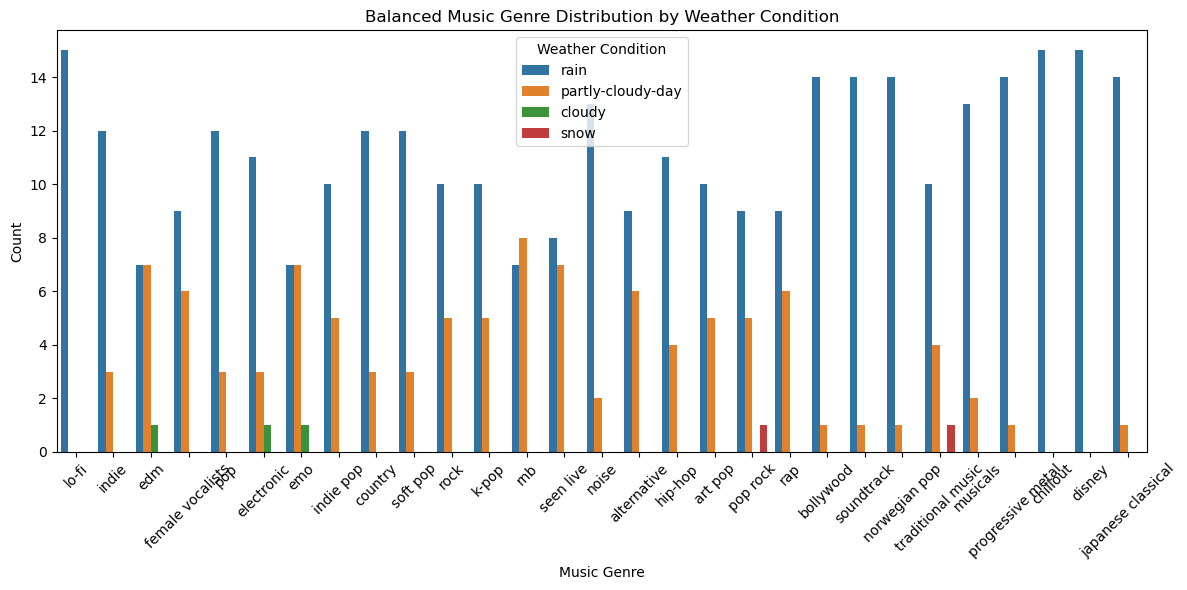

In [11]:
# Histogram: Genre Distribution by Weather Condition
plt.figure(figsize=(12, 6))
sns.countplot(data=sample_data, x='genre', hue='icon')
plt.title("Balanced Music Genre Distribution by Weather Condition")
plt.xticks(rotation=45)
plt.xlabel("Music Genre")
plt.ylabel("Count")
plt.legend(title="Weather Condition")
plt.tight_layout()
plt.show()

In [12]:
contingency_table = pd.crosstab(merged_data['icon'], merged_data['genre'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Test Statistic: {chi2:.3f}")
print(f"P-Value: {p:.3f}")

if p < 0.05:
    print("There is a significant relationship between Weather Condition and Music Genre.")
else:
    print("No significant relationship found between Weather Condition and Music Genre.")

Chi-Square Test Statistic: 1263.320
P-Value: 0.000
There is a significant relationship between Weather Condition and Music Genre.
